### Word Embeddings

## 방준영(20249184)

In [2]:
import gensim.downloader as api

In [5]:
# GloVe - Stanford University
# Word2Vec - Google
model = api.load('glove-wiki-gigaword-50')


In [6]:
model['king']


array([ 0.50451 ,  0.68607 , -0.59517 , -0.022801,  0.60046 , -0.13498 ,
       -0.08813 ,  0.47377 , -0.61798 , -0.31012 , -0.076666,  1.493   ,
       -0.034189, -0.98173 ,  0.68229 ,  0.81722 , -0.51874 , -0.31503 ,
       -0.55809 ,  0.66421 ,  0.1961  , -0.13495 , -0.11476 , -0.30344 ,
        0.41177 , -2.223   , -1.0756  , -1.0783  , -0.34354 ,  0.33505 ,
        1.9927  , -0.04234 , -0.64319 ,  0.71125 ,  0.49159 ,  0.16754 ,
        0.34344 , -0.25663 , -0.8523  ,  0.1661  ,  0.40102 ,  1.1685  ,
       -1.0137  , -0.21585 , -0.15155 ,  0.78321 , -0.91241 , -1.6106  ,
       -0.64426 , -0.51042 ], dtype=float32)

In [8]:
model.vectors.shape

(400000, 50)

### Visualize of Embedding Vectors 해보자


In [13]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt 


In [17]:
model['king'].shape

(50,)

In [23]:
vec = model['king'].reshape(1, -1)

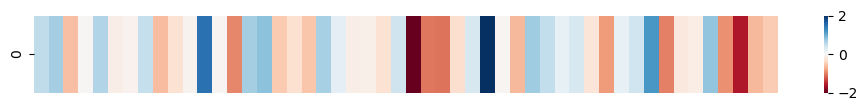

In [30]:
plt.figure(figsize=(12,1))
sns.heatmap(vec, cmap = 'RdBu', vmin=-2, vmax=2)
plt.tick_params(axis='x', bottom=False, labelbottom=False)
plt.show()

In [ ]:
# 컴퓨터가 인식한 king.... 컴퓨터는 vector로 본다. 
# 그림으로 보는 이유는 단어와 비교. 

In [48]:
def plot_embeddings(words):
    n_words = len(words)
    vectors = np.array([model[x] for x in words])

    print(vectors.shape)

    plt.figure(figsize=(12, n_words))
    sns.heatmap(vectors, cmap='RdBu', vmin=-2, vmax=2)

    ax = plt.gca()
    ax.set_yticklabels(words, rotation=0)
    ax.tick_params(axis='both', which='major', labelsize=24)

    plt.tick_params(axis='x', bottom=False, labelbottom=False)
    plt.show()

(4, 50)


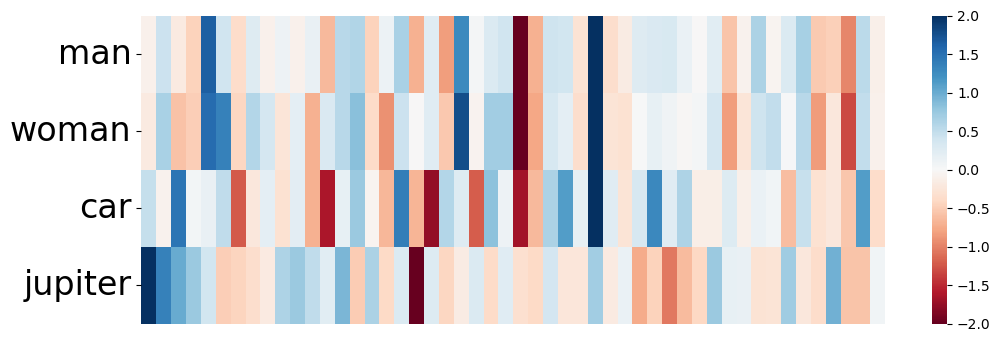

In [49]:
plot_embeddings(['man','woman','car','jupiter'])

### 유사어 찾기 (Similar Words)

In [51]:
model['dog']

array([ 0.11008  , -0.38781  , -0.57615  , -0.27714  ,  0.70521  ,
        0.53994  , -1.0786   , -0.40146  ,  1.1504   , -0.5678   ,
        0.0038977,  0.52878  ,  0.64561  ,  0.47262  ,  0.48549  ,
       -0.18407  ,  0.1801   ,  0.91397  , -1.1979   , -0.5778   ,
       -0.37985  ,  0.33606  ,  0.772    ,  0.75555  ,  0.45506  ,
       -1.7671   , -1.0503   ,  0.42566  ,  0.41893  , -0.68327  ,
        1.5673   ,  0.27685  , -0.61708  ,  0.64638  , -0.076996 ,
        0.37118  ,  0.1308   , -0.45137  ,  0.25398  , -0.74392  ,
       -0.086199 ,  0.24068  , -0.64819  ,  0.83549  ,  1.2502   ,
       -0.51379  ,  0.04224  , -0.88118  ,  0.7158   ,  0.38519  ],
      dtype=float32)

In [52]:
model.most_similar('dog')

[('cat', 0.9218006134033203),
 ('dogs', 0.8513158559799194),
 ('horse', 0.7907583117485046),
 ('puppy', 0.7754921317100525),
 ('pet', 0.7724707722663879),
 ('rabbit', 0.7720814347267151),
 ('pig', 0.7490062117576599),
 ('snake', 0.7399188876152039),
 ('baby', 0.7395570874214172),
 ('bite', 0.738793671131134)]

### King - (Man - Woman) = ?

In [54]:
model.most_similar(positive=['king', 'woman'], negative =['man'])

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.759214460849762),
 ('daughter', 0.7473882436752319),
 ('elizabeth', 0.7460219860076904),
 ('princess', 0.7424570322036743),
 ('kingdom', 0.7337412238121033),
 ('monarch', 0.7214491367340088),
 ('eldest', 0.7184861898422241),
 ('widow', 0.7099431157112122)]

### gender bias?

In [56]:
model.most_similar(positive =['doctor','woman'], negative=['man'])

[('nurse', 0.840464174747467),
 ('child', 0.7663259506225586),
 ('pregnant', 0.7570130228996277),
 ('mother', 0.7517457604408264),
 ('patient', 0.751666247844696),
 ('physician', 0.7507280707359314),
 ('dentist', 0.7360344529151917),
 ('therapist', 0.7342537045478821),
 ('parents', 0.7286345958709717),
 ('surgeon', 0.7165213823318481)]

In [58]:
# 해프닝 검증 nurse?


In [65]:
from sklearn.metrics.pairwise import cosine_similarity

In [72]:
vec = model['doctor'] - model['man'] + model['woman']
vec = vec.reshape(1, -1)

In [73]:
cosine_similarity(vec, model['nurse'].reshape(1, -1))

array([[0.84242684]], dtype=float32)

In [74]:
cosine_similarity(vec, model['doctor'].reshape(1, -1))

array([[0.89598835]], dtype=float32)